In [1]:
import sys
import os
if not any(path.endswith('textbook') for path in sys.path):
    sys.path.append(os.path.abspath('../../..'))
from textbook_utils import *

# Basics of Hypothesis Testing

In our experience, hypothesis testing is one of the more challenging areas of
data science---challenging to learn and challenging to apply. This is not
necessarily because hypothesis testing is deeply technical; rather, hypothesis
testing can be counterintuitive because it makes use of contradictions. As the
name suggests, we often start hypothesis testing with a _hypothesis_: a
statement about the world that we would like to verify.

In an ideal world, we would directly prove our hypothesis is true.
Unfortunately, we often don't have access to all the information needed to
determine the truth. For example, we might hypothesize that a new vaccine is
effective, but contemporary medicine doesn't yet understand all the details of
the biology that govern vaccine efficacy. Instead, we turn to the tools of
probability, random sampling, and data design.

One reason hypothesis testing can be confusing is that it's a lot like "proof
by contradiction," where we assume the opposite of our hypothesis is true and
try to show that the data we observe is inconsistent with that assumption. We
approach the problem this way because often, something can be true for many
reasons, but we only need a single example to contradict an assumption. We call
this "opposite hypothesis" the *null hypothesis* and our original hypothesis
the *alternative hypothesis*.

To make matters a bit more confusing, the tools of probability don't directly
prove or disprove things. Instead, they tell us how likely or unlikely
something we observe is under assumptions, like the assumptions of the null
hypothesis. That's why it's so important to design the data collection well. 

Recall the randomized clinical trial of the J&J vaccine
({numref}`Chapter %s <ch:theory_datadesign>`), where 43,738 people enrolled in the trial were
randomly split into two equal groups. The treatment group was given the
vaccine and the control was given a fake vaccine, called a placebo. This
random assignment created two groups that were similar in every way except for
the vaccine.

In this trial, 117 people in the treatment group fell ill and 351 in the
control group got sick. Since we want to provide convincing evidence that the
vaccine works, we start with a null hypothesis that it doesn't work, meaning it
was just by chance that the random assignment led to so few illnesses in the
treatment group. We can then use probability to calculate the chance of
observing so few sick people in the treatment group. The probability
calculations are based on the urn that has 43,738 marbles in it, with 468
marked 1 to denote a sick person. We then found that the probability of at most
117 marbles being drawn in 21,869 draws with replacement from the urn was
nearly zero. We take this as evidence to reject the null hypothesis in favor of
the alternative hypothesis that the vaccine works. Because the J&J experiment
was well designed, a rejection of the null leads us to conclude that the vaccine
works. In other words, the truth of the hypothesis is left to us and how
willing we are to be potentially wrong.

In the rest of this section, we go over the four basic steps of a hypothesis
test. We then provide two examples that continue two of the examples from
Chapter 3, and delve deeper into the formalities for testing.

There are four basic steps to hypothesis testing:

Step 1: Set up
: You have your data, and you want to test whether a particular model is reasonably consistent with the data. So you specify a statistic, $\hat{\theta}$, such as the sample average, fraction of zeros in a sample, or fitted regression coefficient, with the goal of comparing your data's statistic to what might have been produced under the model.

Step 2: Model
: You spell out the model that you want to test in the form of a data generation mechanism, along with any specific assumptions about the population. This model typically includes specifying $\theta^*$, which may be the population mean, the proportion of zeros, or a regression coefficient. The sampling distribution of the statistic under this model is referred to as the _null distribution_, and the model itself is called the *null hypothesis*.

Step 3: Compute
: How likely, according to the null model in step 2, is it to get data (and the resulting statistic) at least as extreme as what you actually got in step 1?  In formal inference, this probability is called the $p$-*value*. To approximate the $p$-value, we often use the computer to generate a large number of repeated random trials using the assumptions in the model and find the fraction of samples that give a value of the statistic at least as extreme as our observed value. Other times, we can instead use mathematical theory to find the $p$-value.
  
Step 4: Interpret
: The $p$-value is used as a measure of surprise.  If the model that you spelled out in step 2 is believable, how surprised should you be to get the data (and summary statistic) that you actually got?  A moderately sized $p$-value means that the observed statistic is pretty much what you would expect to get for data generated by the null model.  A tiny $p$-value raises doubts about the null model. In other words, if the model is correct (or approximately correct), then it would be very unusual to get such an extreme value of the test statistic from data generated by the model.  In this case, either the null model is wrong or a very unlikely outcome has occurred. Statistical logic says to conclude that the pattern is real; that it is more than just coincidence.  Then it's up to you to explain why the data generation process led to such an unusual value. This is when a careful consideration of the scope is important. 

Let's demonstrate these steps in the testing process with a couple of examples. 

## Example: A Rank Test to Compare Productivity of Wikipedia Contributors 

Recall the Wikipedia example from {numref}`Chapter %s <ch:data_scope>`, where a randomly selected set of 200 contributors were chosen from among the top 1\% of contributors who were active in the past 30 days on the English-language Wikipedia and who had never received an award.  These 200 contributors were divided at random into two groups of 100. The contributors in one group, the treatment group, were each given an informal award, while no one in the other group was given one. All 200 contributors were followed for 90 days and their activity on Wikipedia recorded. 

It has been conjectured that informal awards have a reinforcing effect on volunteer work, and this experiment was designed to formally study this conjecture. We carry out a hypothesis test based on the rankings of the data. 

First, we read the data into a dataframe:

In [2]:
wiki = pd.read_csv("data/Wikipedia.csv")
wiki.shape

(200, 2)

In [3]:
wiki.describe()[3:]

,experiment,postproductivity
min,0.0,0.0
25%,0.0,57.5
50%,0.5,250.5
75%,1.0,608.0
max,1.0,2344.0


The dataframe has 200 rows, one for each contributor. The feature `experiment` is either 0 or 1, depending on whether the contributor was in the control or treatment group, respectively; and `postproductivity` is a count of the edits made by the contributor in the 90 days after the awards were made. The gap between the quartiles (lower, middle, and upper) suggests the distribution of productivity is skewed. We make a histogram to confirm:

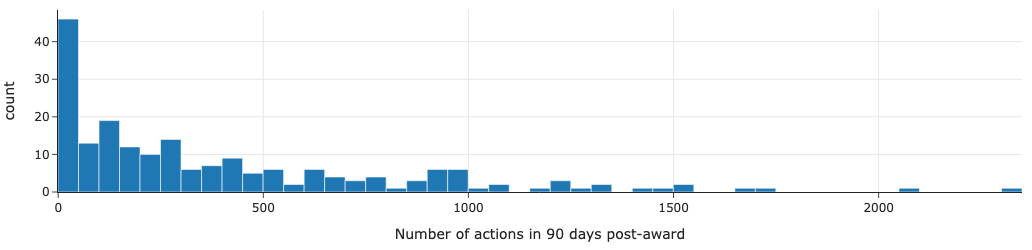

In [ ]:
px.histogram(wiki, x='postproductivity', nbins=50,
             labels={'postproductivity':'Number of actions in 90 days post-award'},
             width=350, height=250)

Indeed, the histogram of post-award productivity is highly skewed, with a spike near zero. The skewness suggests a statistic based on the ordering of the values from the two samples.  

To compute our statistic, we order all productivity values (from both groups) from smallest to largest. The smallest value has rank 1, the second smallest rank 2, and so on, up to the largest value, which has a rank of 200. We use these ranks to compute our statistic, $\hat{\theta}$, which is the average rank of the treatment group. We chose this statistic because it is insensitive to highly skewed distributions. For example, whether the largest value is 700 or 700,000, it still receives the same rank, namely 200. If the informal award incentivizes contributors, then we would expect the average rank of the treatment group to be typically higher than the control. 

The null model assumes that an informal award has *no* effect on productivity, and any difference observed between the treatment and control groups is due to the chance process in assigning contributors to groups. The null hypothesis is set up for the status quo to be rejected; that is, we hope to find a surprise in assuming no effect. 

The null hypothesis can be represented by 100 draws from an urn with 200 marbles, marked 1, 2, 3, ..., 200. In this case, the average rank would be $(1 + 200)/2 = 100.5$ 

We use the `rankdata` method in `scipy.stats` to rank the 200 values and compute the sum of ranks in the treatment group:

In [5]:
from scipy.stats import rankdata
ranks = rankdata(wiki['postproductivity'], 'average')

Let's confirm that the average rank of the 200 values is 100.5:

In [6]:
np.average(ranks)

100.5

And find the average rank of the 100 productivity scores in the treatment group:

In [7]:
observed = np.average(ranks[100:])
observed

113.68

The average rank in the treatment group is higher than expected, but we want to figure out if it is an unusually high value. We can use simulation to find the sampling distribution for this statistic to see if 113 is a routine value or a surprising one. 

To carry out this simulation, we set up the urn as the `ranks` array from the data. Shuffling the 200 values in the array and taking the first 100 represents a randomly sampled treatment group. We write a function to shuffle the array of ranks and find the average of the first 100.

In [8]:
rng = np.random.default_rng(42)
def rank_avg(ranks, n):
    rng.shuffle(ranks)
    return np.average(ranks[n:])      

Our simulation mixes the marbles in the urn, draws 100 times, computes the
average rank for the 100 draws, and repeats this 100,000 times.

In [9]:
rank_avg_simulation = [rank_avg(ranks, 100) for _ in range(100_000)] 

Here is a histogram of the simulated averages:

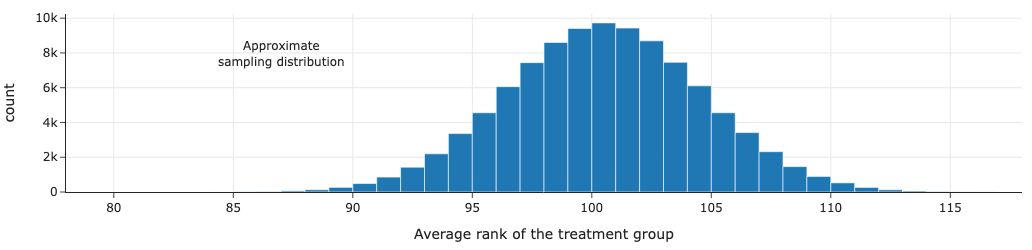

In [10]:
fig = px.histogram(x=rank_avg_simulation, nbins=50,
    labels=dict(x="Average rank of the treatment group"),
    width=350, height=250,
)
fig.add_annotation(
    x=87, y=8000, showarrow=False, text="Approximate<br>sampling distribution"
)
fig.show()

As we expected, the sampling distribution of the average rank is centered on 100 (100.5 actually) and is bell-shaped. The center of this distribution reflects the assumptions of the treatment having no effect. Our observed statistic is well outside the typical range of simulated average ranks, and we use this simulated sampling distribution to find the approximate $p$-value for observing a statistic at least as big as ours:

In [11]:
np.mean(rank_avg_simulation > observed)

0.00052

This is a big surprise. Under the null, the chance of seeing an average rank at least as large as ours is about 5 in 10,000. 

This test raises doubt about the null model. Statistical logic has us conclude that the pattern is real. How do we interpret this? The experiment was well designed. The 200 contributors were selected at random from the top 1%, and then they were divided at random into two groups. These chance processes say that we can rely on the sample of 200 being representative of top contributors, and on the treatment and control groups being similar to each other in every way except for the application of the treatment (the award). Given the careful design, we conclude that informal awards have a positive effect on productivity for top contributors.

Earlier, we implemented a simulation to find the $p$-value for our observed
statistic. In practice, rank tests are commonly used and made available in most
statistical software:

In [12]:
from scipy.stats import ranksums

ranksums(x=wiki.loc[wiki.experiment == 1, 'postproductivity'],
         y=wiki.loc[wiki.experiment == 0, 'postproductivity'])

RanksumsResult(statistic=3.220386553232206, pvalue=0.0012801785007519996)

The $p$-value here is twice the $p$-value we computed because we considered only values greater than the observed, whereas the `ranksums` test computed the the $p$-value for both sides of the distribution. In our example, we are only interested in an increase in productivity, and so use a one-sided $p$-value, which is half the reported value (0.0006) and close to our simulated value.

This somewhat unusual test statistic that uses ranks rather than the actual data values was developed in the 1950s and 1960s, before today's era of powerful laptop computers. The mathematical properties of rank statistics is well developed and the sampling distribution is well behaved (it is symmetric and shaped like the bell curve even for small datasets). Rank tests remain popular for A/B testing where samples tend to be highly skewed, and it is common to carry out many, many tests where $p$-values can be computed rapidly from the normal distribution.

The next example revisits the vaccine efficacy example from {numref}`Chapter %s <ch:theory_datadesign>`. There, we encountered a hypothesis test without actually calling it that.  

## Example: A Test of Proportions for Vaccine Efficacy

The approval of a vaccine is subject to stricter requirements than the simple test we performed earlier where we compared the disease counts in the treatment group to those of the control group. The CDC requires stronger evidence of success based on a comparison of the proportion of sick individuals in each group. To explain, we express the sample proportion of sick people in the control and treatment groups as $\hat{p}_{C}$ and $\hat{p}_T$, respectively, and use these proportions to compute vaccine efficacy:  

$$ 
\hat{\theta} = \frac {\hat{p}_{C} - \hat{p}_T} {\hat{p}_C} = 1 - \frac {\hat{p}_T} {\hat{p}_C}
$$

The observed value of vaccine efficacy in the J\&J trial is:

$$ 
1 - \frac{117/21869} {351/21869} = 1- \frac{117}{351} = 0.667
$$

If the treatment doesn't work, the efficacy would be near 0. The CDC sets a standard of 50% for vaccine efficacy, meaning that the efficacy has to exceed 50% to be approved for distribution. In this situation, the null model assumes that vaccine efficacy is 50% ($\theta^* = 0.5$), and any difference of the observed value from the expected is due to the chance process in assigning people to groups. Again, we set the null hypothesis to be the status quo that the vaccine isn't effective enough to warrant approval, and we hope to find a surprise and reject the null. 

With a little algebra, the null model $0.5 = 1 - p_T / p_C$ reduces to $p_T = 0.5 p_C$.  That is, the null hypothesis implies that the proportion of ill people among those receiving the treatment is at most half that of the control. Notice that the actual values for the two risks ($p_T$ and $p_C$) are not assumed in the null.  That is, the model doesn't assume the treatment doesn't work, but rather, that its efficacy is no larger than 0.5. 

Our urn model in this situation is a bit different from what we set up in {numref}`Chapter %s <ch:theory_datadesign>`.  The urn still has 43,738 marbles in it, corresponding to the enrollees in the experiment. But now each marble has two numbers on it, which for simplicity appear in a pair, such as $(0, 1)$. The number on the left is the response if the person receives the treatment, and the number on the right corresponds to the response to no treatment (the control). As usual, 1 means they become ill and 0 means they stay healthy. 

The null model assumes that the proportion of ones on the left of the pair is half the proportion on the right. Since we don't know these two proportions, we can use the data to estimate them. There are three types of marbles in the urn $(0,0)$, $(0,1)$, and $(1, 1)$. We assume that $(1, 0)$, which corresponds to a person getting ill under treatment and not under control, is not possible.  We observed 351 people getting sick in control and 117 in treatment. With the assumption that the treatment rate of illness is  half that of the control, we can tray a scenario for the makeup of the urn. For example, we can study the case where 117 people in treatment didn't get sick but would have if they were in the control group, so combined, all 585 people ($351 + 117 + 117$) would get the virus if they didn't receive the vaccine and half of them would not get the virus if they received treatment. {numref}`Table %s <vacc-urn>` shows these counts.  

:::{table} Vaccine trial urn
:name: vacc-urn

| Label   | Count  |
|---------|--------|
| (0, 0)  | 43,152 |
| (0, 1)  |    293 |
| (1, 0)  |      0 |
| (1, 1)  |    293 |
|Total    | 43,738 |

:::

We can use these counts to carry out a simulation of the clinical trial and compute vaccine efficacy. As shown in {numref}`Chapter %s <ch:theory_datadesign>`, the multivariate hypergeometric function simulates draws from an urn when there are more than two kinds of marbles. We set up this urn and sampling process:

In [13]:
N = 43738
n_samp = 21869
N_groups = np.array([293, 293, (N - 586)])

from scipy.stats import multivariate_hypergeom

def vacc_eff(N_groups, n_samp):
    treat = multivariate_hypergeom.rvs(N_groups, n_samp)
    ill_t = treat[1]
    ill_c = N_groups[0] - treat[0] + N_groups[1] - treat[1]
    return (ill_c - ill_t) / ill_c

Now we can simulate the clinical trial 100,000 times and calculate the vaccine efficacy for each trial:

In [14]:
np.random.seed(42)
sim_vacc_eff = np.array([vacc_eff(N_groups, n_samp) for _ in range(100_000)])

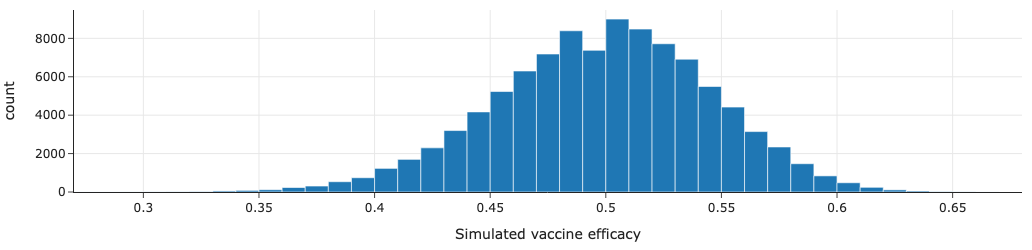

In [ ]:
px.histogram(x=sim_vacc_eff, nbins=50,
            labels=dict(x='Simulated vaccine efficacy'),
            width=350, height=250)

The sampling distribution is centered at 0.5, which agrees with our model assumptions. We see that 0.667 is far out in the tail of this distribution: 

In [16]:
np.mean(sim_vacc_eff > 0.667)

1e-05

Only a tiny handful of the 100,000 simulations have a vaccine efficacy as large
as the observed 0.667. This is a rare event, and that's why the CDC approved
the Johnson & Johnson vaccine for distribution.  

In this example of hypothesis testing, we were not able to completely specify
the model, and we had to provide approximate values for $p_C$ and $p_T$ based on
our observed values of $\hat{p}_C$ and $\hat{p}_T$. At times, the null model
isn't entirely specified, and we must rely on the data to set up the model. The
next section introduces a general approach, called the bootstrap, to
approximate the model using the data.